In [ ]:
try:
    import matplotlib.pyplot as plt
    import numpy as np
    import torch
    import torch.nn as nn
except ModuleNotFoundError:
    %pip install -r requirements.txt


np.random.seed(0)
torch.random.manual_seed(0)

plt.rcParams['font.size'] = 16
plt.rcParams['lines.markersize'] = 10


## 1. Problem Setup
We solve the 1D simple harmonic oscillator:
m·d²x/dt² + k·x = 0

with m=1, k=1, x(0)=1, x'(0)=0.
The exact solution is x(t) = cos(t).

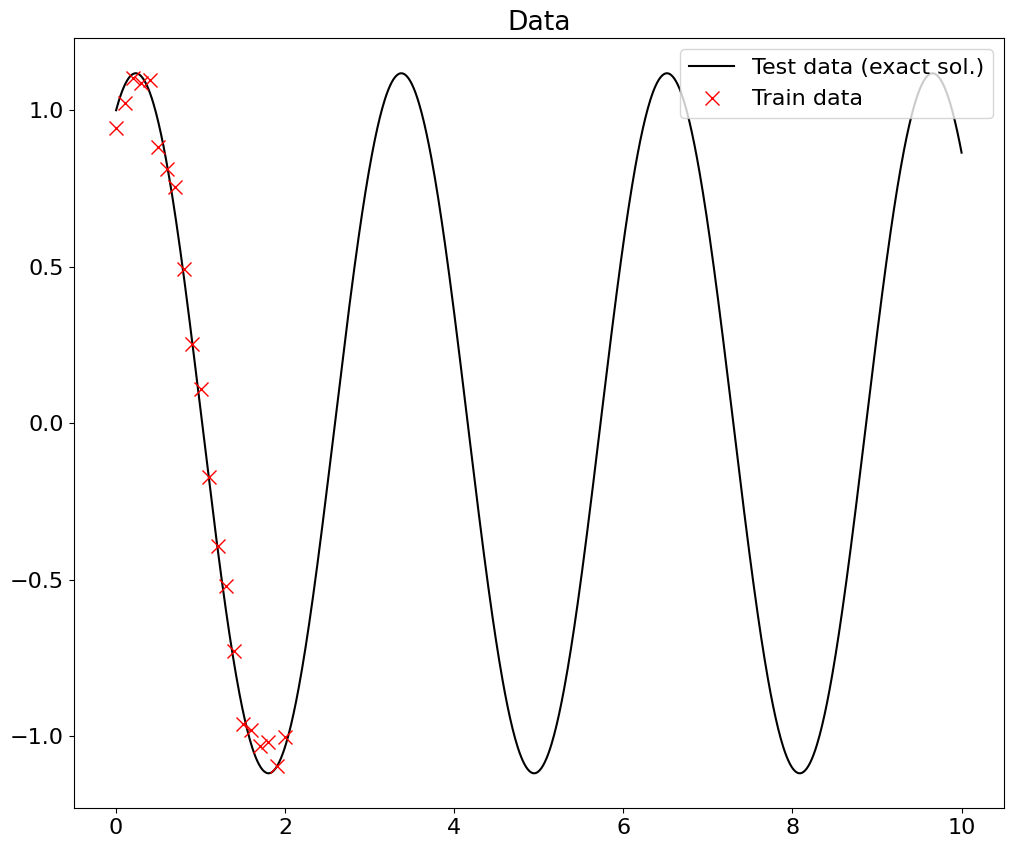

In [ ]:
# ODE parameters
m = 1
k = 4

# ODE initial value
x0 = 1
v0 = 1

# Data generation parameters
N_TRAIN = 20
TMAX_TRAIN = 2
NOISE_STD = 0.05

N_TEST = 1000
TMAX_TEST = 10

def exact_solution(t, k, m):
    w = np.sqrt(k / m)
    A = np.sqrt(x0 ** 2 + (v0 / w) ** 2)
    # Convert the numpy float to a torch tensor before passing to torch.arctan
    Phi = torch.arctan(torch.tensor(x0 * w / v0, dtype=t.dtype))

    x = A * torch.sin(w * t + Phi)
    return x


t_train = torch.linspace(0, TMAX_TRAIN, N_TRAIN + 1).unsqueeze(-1)
t_test = torch.linspace(0, TMAX_TEST, N_TEST + 1).unsqueeze(-1)

x_train = exact_solution(t_train, k, m) + NOISE_STD * torch.randn_like(t_train)
x_test = exact_solution(t_test, k, m)

plt.figure(figsize = (12, 10))
plt.plot(t_test, x_test, "k-", label="Test data (exact sol.)")
plt.plot(t_train, x_train, "rx", label="Train data")
plt.title("Data")
plt.legend(loc='upper right')

## 2. Neural Network Architecture
A simple feed-forward network with 1 inputs and
32 hidden layers, Tanh() activation.

In [ ]:
class NeuralNet(nn.Module):
    """Defines a pytorch neural network with one hidden layer."""

    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, output_size),
        )

    def forward(self, x):
        return self.network(x)

def train_nn(model, t_train, x_train, nepochs=10000, learning_rate=5e-3):
    mse = nn.MSELoss()
    torch.manual_seed(123)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    for i in range(nepochs):
        optimizer.zero_grad()

        # compute data loss
        x_pred = model(t_train)
        loss = mse(x_pred, x_train)

        # backward pass and update parameters
        loss.backward()
        optimizer.step()

        print(f"loss = {loss.item()}") if i % 500 == 0 else None


model_nn = NeuralNet()
train_nn(model_nn, t_train=t_train, x_train=x_train)

loss = 0.7994154691696167
loss = 0.00167402857914567
loss = 0.001449896371923387
loss = 0.0013808024814352393
loss = 0.001289312494918704
loss = 0.0011955579975619912
loss = 0.0011547503527253866
loss = 0.001124089933000505
loss = 0.0010836260626092553
loss = 0.0010267498437315226
loss = 0.0009876955300569534
loss = 0.0009654853492975235
loss = 0.0009469318902119994
loss = 0.000870685325935483
loss = 0.0005112921935506165
loss = 0.00015874743985477835
loss = 8.3217877545394e-05
loss = 5.1079543482046574e-05
loss = 3.668693170766346e-05
loss = 1.806422005756758e-05


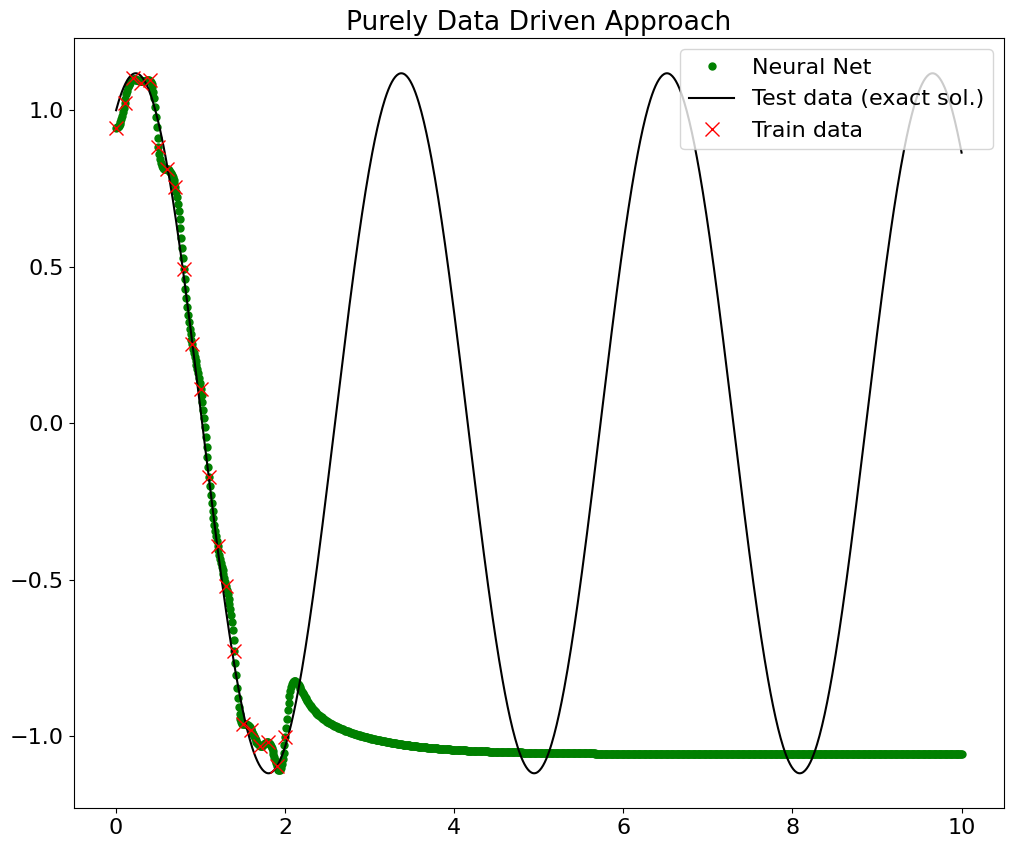

In [ ]:
plt.figure(figsize=(12, 10))
plt.plot(t_test, model_nn(t_test).detach().numpy(), "g.", label="Neural Net")
plt.plot(t_test, x_test, "k-", label="Test data (exact sol.)")
plt.plot(t_train, x_train, "rx", label="Train data")
plt.title("Purely Data Driven Approach")
plt.legend(loc = 'upper right')

## 3. Loss Function
Total loss = Data loss (i.c., b.c.) + Physics loss (ODE residual)

L_total = L_IC + λ·L_physics

In [ ]:
# choose points to evaluate the physics loss with
TMAX_PHYS = 7
N_PHYS = 1000

t_phys = np.random.uniform(0, TMAX_PHYS, N_PHYS)

model_pinn = NeuralNet(1, 32, 1)


def time_derivative(x, t):
    xdot = torch.autograd.grad(x, t, torch.ones_like(x), create_graph=True)[0]
    return xdot


def train_pinn(model, t_train, x_train, t_phys, nepochs=10000, learning_rate=5e-3):
    lambda_ = 1
    mse = nn.MSELoss()
    t_phys = torch.tensor(t_phys, requires_grad=True, dtype=torch.float32).reshape(-1, 1)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # The global k and MU are available.
    for i in range(nepochs):
        optimizer.zero_grad()

        # compute data loss
        x_pred = model(t_train)
        loss = mse(x_pred, x_train)

        # compute physics loss
        x_phys = model(t_phys)
        xdot = time_derivative(x_phys, t_phys)
        xddot = time_derivative(xdot, t_phys)

        ode_residual = m * xddot + k * x_phys
        loss += lambda_ * torch.mean(ode_residual**2)

        # backward pass and update params
        loss.backward()
        optimizer.step()
        print(f"loss = {loss.item()}") if i % 500 == 0 else None


train_pinn(model_pinn, t_train, x_train, t_phys)

loss = 1.0152716636657715
loss = 0.19543997943401337
loss = 0.18495523929595947
loss = 0.14786024391651154
loss = 0.021684084087610245
loss = 0.007180524989962578
loss = 0.0028997245244681835
loss = 0.0024326113052666187
loss = 0.0022091809660196304
loss = 0.0021081408485770226
loss = 0.006295102182775736
loss = 0.002027141395956278
loss = 0.001961528556421399
loss = 0.0019415405113250017
loss = 0.0025981487706303596
loss = 0.0018612941494211555
loss = 0.00182227639015764
loss = 0.0017907731235027313
loss = 0.0017823745729401708
loss = 0.0017651412636041641


## 4. Training and Result
After 10000 epochs, the PINN solution closely matches
the analytical solution. The figure below shows the comparison.

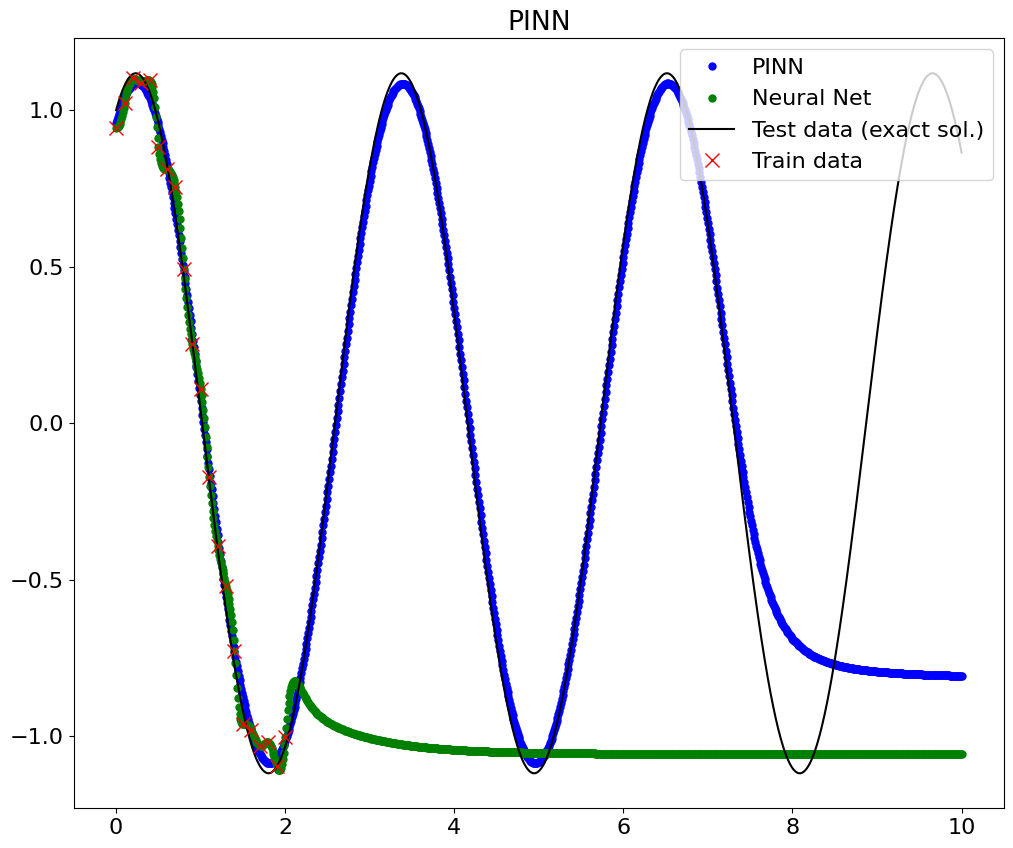

In [ ]:
plt.figure(figsize=(12, 10))

plt.plot(t_test, model_pinn(t_test).detach().numpy(), "b.", label="PINN")
plt.plot(t_test, model_nn(t_test).detach().numpy(), "g.", label="Neural Net")
plt.plot(t_test, x_test, "k-", label="Test data (exact sol.)")
plt.plot(t_train, x_train, "rx", label="Train data")
plt.title("PINN")
plt.legend(loc = 'upper right')

## 5. Reflection
- What worked well: The PINN demonstrated high robustness to noise and showed superior extrapolation capabilities compared to the standard neural network.

- What I learned: Working with the mass_spring_system_solutions.ipynb file was a great opportunity to observe PINN's strengths and weaknesses. I noticed two key things: first, PINN provides a more generalized solution that works even outside the training set, possibly by avoiding the local minima that trap standard NNs. Second, I discovered a trade-off in performance, as the training speed is slower than vanilla deep learning because of the continuous evaluation of physics constraints.

- Next step: extend to damped oscillator